**Fundamentals of Machine Learning - Exercise 2** 💪
---

---
### 🎯 Aim of the Exercise

In this exercise, you will learn how to perform **Exploratory Data Analysis (EDA)** by:

- 🏷️ understanding **variable types** and working with data types,
- ❓ identifying **missing values and potential outliers**,
- 📏 calculating and interpreting **descriptive statistics**,
- 📊 using visualizations to explore **distributions, relationships, and patterns** in the data.

### Import libraries 📘

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import data 🚢

In [7]:
df= sns.load_dataset("titanic")

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> Let's Explore the Data! 🔍 </font></h2>
</div>

- Exploratory Data Analysis (EDA) starts with understanding our data.

- Let's begin with a quick inspection of the dataset.

Let's display the first few rows of the dataset.

In [8]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


🧩 Take a look at the columns. What can you identify from the first few rows?

Let's check the basic information about the DataFrame

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


🧩 Look at the data types reported by info(). Do they always tell us what the variables actually represent?

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> Understanding Variable Types 🏷️  </font></h2>
</div>  

### Numerical Variables

In [10]:
df["age"].unique()[:10]

array([22., 38., 26., 35., nan, 54.,  2., 27., 14.,  4.])

`age` is stored as a `float` and represents a numerical variable.

### Categorical Variables Stored as Integers
Some variables are stored as numbers, but the numbers actually represent categories.

In [11]:
df["survived"].unique()

array([0, 1])

🧩 "survived" is stored as an integer. But what do the values 0 and 1 actually represent?

🧩 What about "pclass"?

In [12]:
df["pclass"].unique()

array([3, 1, 2])

💡 pclass represents ordered categories (1st, 2nd, and 3rd class) => ordinal categorical variable.

💡 A Pandas "dtype" tells us how the data are stored, not necessarily what the variable represents statistically.

| Variable   | Pandas `dtype` | Variable type         |
| ---------- | -------------- | --------------------- |
| `age`      | `float64`      | Numerical             |
| `fare`     | `float64`      | Numerical             |
| `sex`      | `str`       | Categorical (nominal) |
| `survived` | `int64`        | Categorical (binary)  |
| `pclass`   | `int64`        | Categorical (ordinal) |


💡 A quick inspection is an important first step in EDA. It helps us understand what our dataset looks like before we analyze it in more detail.

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> Converting Data Types 🔄  </font></h2>
</div>

- Once we understand what the variables represent, we can convert selected columns to more appropriate data types.

🧩 Do all categorical variables need to have the Pandas category dtype?

- Not necessarily. Categorical variables can also be stored as strings or integers.

- However, converting a variable to category simply makes its categorical meaning explicit in Pandas.


string → category

In [13]:
df["sex"].dtype

<StringDtype(na_value=nan)>

In [14]:
df["sex"] = df["sex"].astype("category")

In [15]:
df["sex"].dtype

CategoricalDtype(categories=['female', 'male'], ordered=False, categories_dtype=str)

💡 .astype() can be used to convert a column to another data type.

🧩 survived is also a categorical variable. Why might we keep it as an integer (0 and 1) instead of converting it to category?

💡 Keeping survived as 0 and 1 allows us to calculate useful statistics directly. For example, its mean represents the proportion of passengers who survived.

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> Redundant variables 🔁</font></h2>
</div>

During EDA, we should also check whether different columns contain the same or closely related information.

In [16]:
df[["survived", "alive",
    "pclass", "class",
    "embarked", "embark_town", 
    "sex", "who", "adult_male"]].head()

,survived,alive,pclass,class,embarked,embark_town,sex,who,adult_male
0,0,no,3,Third,S,Southampton,male,man,True
1,1,yes,1,First,C,Cherbourg,female,woman,False
2,1,yes,3,Third,S,Southampton,female,woman,False
3,1,yes,1,First,S,Southampton,female,woman,False
4,0,no,3,Third,S,Southampton,male,man,True


🧩 Which variables appear to contain the same information in different forms?

💡 Some variables contain the same information in different representations:

- survived and alive
- pclass and class
- embarked and embark_town

These variables are redundant because they represent the same underlying information.

But variables that look similar are not necessarily redundant. Let's compare sex, who, and adult_male.

In [17]:
df[["sex", "who", "adult_male"]].drop_duplicates()

,sex,who,adult_male
0,male,man,True
1,female,woman,False
7,male,child,False
9,female,child,False


🧩 Do these three variables contain exactly the same information?

💡 drop_duplicates() shows only the unique combinations of values.

💡 Related variables are not necessarily redundant. Always consider what the variable actually represents.

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> Missing values❓</font></h2>
</div>

- During the initial inspection, we noticed that some columns contain missing values. Let's examine them more closely:

In [18]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

🧩 Which variables contain missing values?

- Let's also look at the percentage of missing values:

In [19]:
(df.isna().mean() * 100).round(1)

survived        0.0
pclass          0.0
sex             0.0
age            19.9
sibsp           0.0
parch           0.0
fare            0.0
embarked        0.2
class           0.0
who             0.0
adult_male      0.0
deck           77.2
embark_town     0.2
alive           0.0
alone           0.0
dtype: float64

🧩 Would you handle the missing values in embarked, age, and deck in the same way? Why or why not?

In [20]:
df["deck"].value_counts(dropna=False)

deck
NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4
Name: count, dtype: int64

💡 "dropna=False" includes missing values in the counts.

🧩 Would you remove deck based only on the percentage of missing values?

💡 Not necessarily. Before removing a variable, we should consider both the amount of missing data and whether the available information could still be useful.

#### 🛠️ <font color='#05c3de'> Handling Missing Values </font>

There are several ways to handle missing values. Let's look at some common options.

#### **1. Remove a column**

In [21]:
df.drop(columns=["deck"])

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True


💡 This returns a DataFrame without deck. The original df remains unchanged.

#### **2. Remove rows containing missing values**

#### .dropna()

In [22]:
df.dropna()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


💡 dropna() removes rows containing at least one missing value.

🧩 Would this be a good strategy for the Titanic dataset? Why or why not?

In [23]:
print("Original:", df.shape)
print("After dropna():", df.dropna().shape)

Original: (891, 15)
After dropna(): (182, 15)


#### **3. Remove rows based on a specific column**

In [24]:
df.dropna(subset=["age"])

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


💡 This removes only rows where age is missing.

🧩 What would be the disadvantage of this approach?

#### **4. Replace missing values**

Removing data is not the only option. Missing values can also be replaced with an estimated value. This is called **imputation**.

- ####  fillna()

In [25]:
df["age"].fillna(df["age"].median())

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

💡 Here we only demonstrate the method. We are not modifying the original DataFrame.

#### Cheat Sheet

| Approach             | Example                     | What does it do?                    |
| -------------------- | --------------------------- | ----------------------------------- |
| Remove a column      | `df.drop(columns=["deck"])` | Removes the entire variable         |
| Remove rows          | `df.dropna()`               | Removes rows with any missing value |
| Remove selected rows | `df.dropna(subset=["age"])` | Removes rows where `age` is missing |
| Replace values       | `df["age"].fillna(...)`     | Replaces missing values             |


💡 There is no universally correct way to handle missing values. Before removing or replacing data, we should consider how much data is missing, what the variable represents, and how it will be used...

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'> Plot First 👀,  Ask Questions Later  </font></h2>
</div>

- Before calculating summary statistics, let's visualize the data first.
- Visualizations can reveal distributions, patterns, unusual observations, and relationships that may not be obvious from a table of values.

Let's start by looking at the distribution of passenger ages.

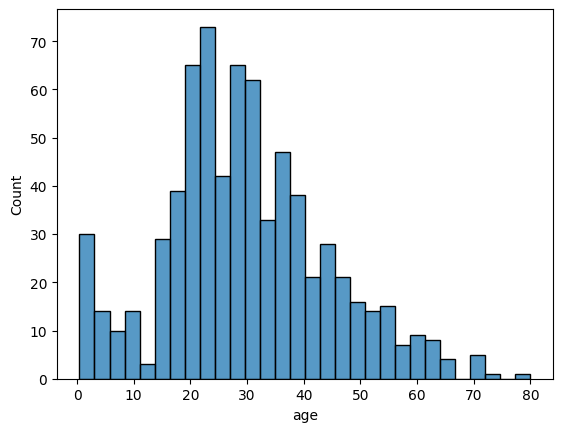

In [26]:
sns.histplot(data=df, x="age", bins=30)
plt.show()

🧩 What do you notice about the shape of the distribution? Is it approximately symmetric or skewed?

Now let's compare it with another numerical variable.

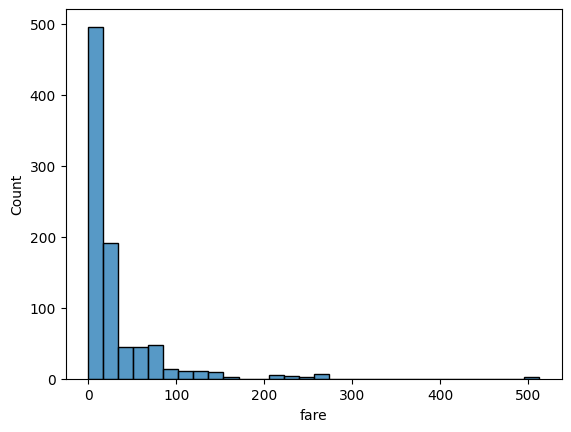

In [27]:
sns.histplot(data=df, x="fare", bins=30)
plt.show()

🧩 How does the distribution of fare differ from the distribution of age?

💡 The distribution of fare is right-skewed

🧩 Do you think the mean and median fare will be similar? Why or why not?

In [28]:
print("Mean fare:", df['fare'].mean())
print("Median fare:", df['fare'].median())

Mean fare: 32.204207968574636
Median fare: 14.4542


🧩 Why is the mean much higher than the median?

# Outlier Detection using Boxplot

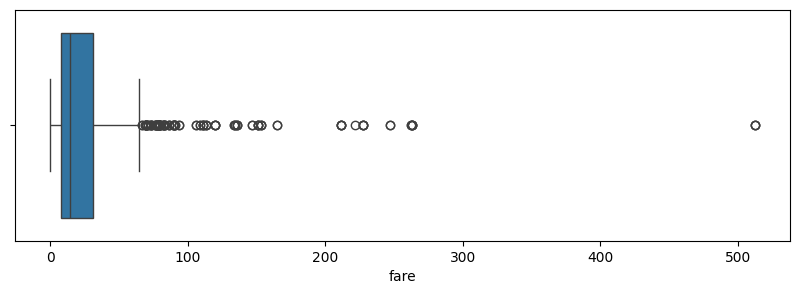

In [29]:
plt.figure(figsize=(10, 3))
sns.boxplot(data=df, x="fare")
plt.show()

🧩 Do you remember how a boxplot identifies potential outliers?

#### Let's break it down

In [31]:
Q1 = np.percentile(df["fare"], 25)
Q3 = np.percentile(df["fare"], 75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
# Common "boxplot fence" is 1.5 * IQR below Q1 or above Q3
outliers = df[(df["fare"] < lower_fence) | (df["fare"] > upper_fence)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower fence: {lower_fence:.2f}")
print(f"Upper fence: {upper_fence:.2f}")
print("Number of potential outliers:", len(outliers))

Q1: 7.91
Q3: 31.00
IQR: 23.09
Lower fence: -26.72
Upper fence: 65.63
Number of potential outliers: 116


💡 Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are commonly identified as potential outliers.

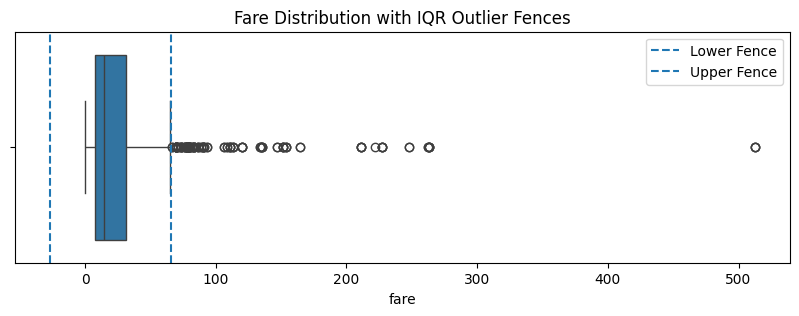

In [32]:
plt.figure(figsize=(10, 3))

sns.boxplot(data=df, x="fare")

plt.axvline(lower_fence, linestyle="--", label="Lower Fence")
plt.axvline(upper_fence, linestyle="--", label="Upper Fence")

plt.title("Fare Distribution with IQR Outlier Fences")
plt.legend()
plt.show()

🧩 Are all observations beyond the upper fence necessarily errors?

🧩 What happens when we examine fare separately for each passenger class?

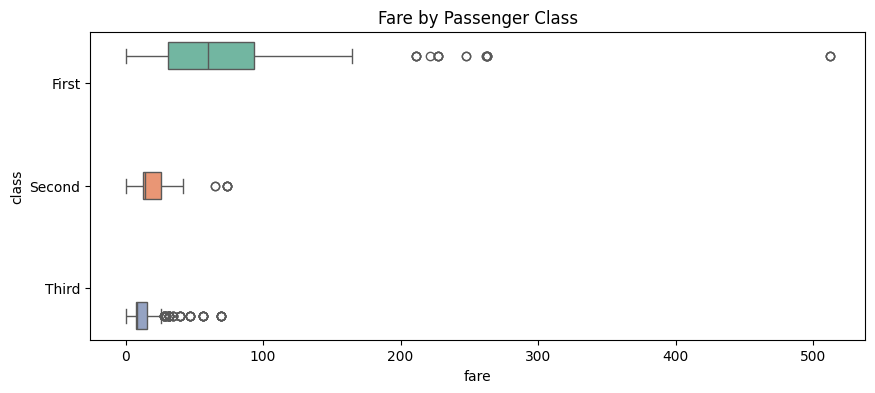

In [33]:
plt.figure(figsize=(10, 4))

sns.boxplot(data=df, x="fare", y="class", hue="class", palette="Set2", legend=False)
plt.title("Fare by Passenger Class")
plt.show()

🧩 Could some of the high fares identified as potential outliers be related to passenger class?

💡 An observation that appears unusual in the entire dataset may be less unusual within a particular group. Context matters when interpreting outliers.

💡 Potential outliers should not be removed automatically.   
Before deciding what to do with them, we should investigate whether they are errors or valid observations and consider the context in which they occur.

💡 There are other methods for detecting unusual observations, such as z-scores or quantile-based thresholds. The choice of method depends on the distribution and the purpose of the analysis.

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'>Descriptive Statistics </font></h2>
</div>

In [22]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


🧩 Look at age and fare. What can you learn about their center, spread, and range from this table?

 `describe()` provides several useful summary statistics:

- `count` – number of non-missing observations
- `mean` – average value
- `std` – standard deviation
- `min` and `max` – range of observed values
- `25%`, `50%`, `75%` – quartiles (`50%` is the median)

🧩 Why is count for age lower than for fare?

🧩 Can you find the mean and median fare in the output of describe()? What do they tell us about its distribution?

🧩 Which variable shows greater variability: age or fare?

💡 The standard deviation (std) describes how spread out the values are around the mean. A larger standard deviation indicates greater variability.

 ### What about a Binary variable?

In [34]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

🧩 What does the mean of a binary variable encoded as 0 and 1 represent?

In [35]:
df["survived"].mean()

np.float64(0.3838383838383838)

💡 When a binary variable is encoded as 0 and 1, its mean represents the proportion of observations with the value 1

Now we can see why keeping "survived" encoded as 0 and 1 can be useful.

<div style="background-color: #05c3de; padding: 20px;">
    <h2><font color='white'>Exploring Relationships </font></h2>
</div>

- So far, we have explored individual variables separately.

- Now let's explore relationships between variables using visualizations and summary statistics.

#### 1. Survival and Sex

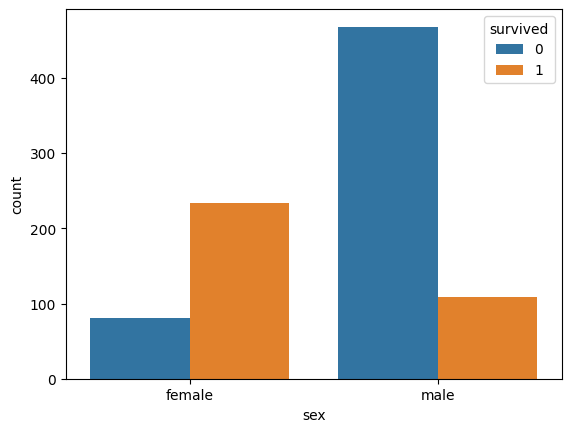

In [36]:
sns.countplot(data=df, x="sex", hue="survived")
plt.show()

🧩 Does survival appear to differ between male and female passengers?

Let's compare the survival rates numerically.

In [37]:
df.groupby("sex", observed=True)["survived"].mean()

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

🧩 Which group had a higher survival rate?

💡 Since survived is encoded as 0 and 1, the group mean represents the survival rate.

#### 2. Survival and Passenger Class

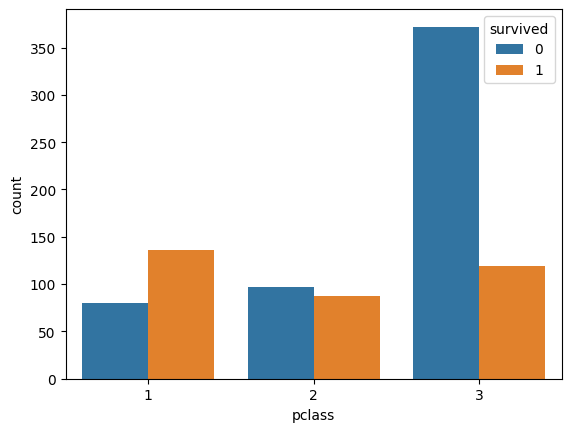

In [38]:
sns.countplot(data=df, x="pclass", hue="survived")
plt.show()

🧩 Does the countplot directly show the probability of survival within each class?

In [39]:
df.groupby("pclass")["survived"].mean()

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

🧩 How does the survival rate change across passenger classes?

#### 3. Age and Passenger Class

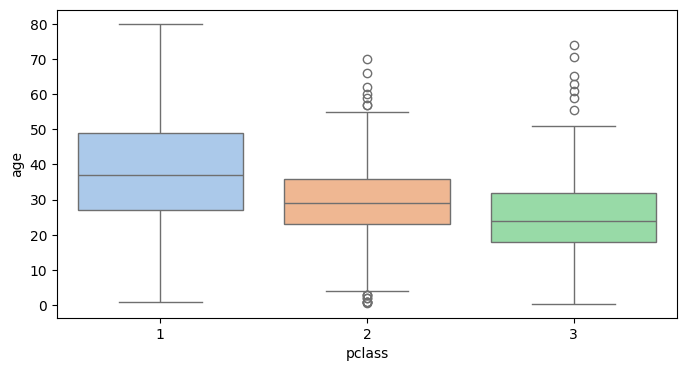

In [40]:
plt.figure(figsize=(8, 4))

sns.boxplot(data=df,x="pclass",y="age",hue="pclass",palette="pastel",legend=False)

plt.show()

In [41]:
df.groupby("pclass")["age"].median()

pclass
1    37.0
2    29.0
3    24.0
Name: age, dtype: float64

🧩 Do the median ages support what you observed in the boxplot?

💡 An observed relationship does not necessarily imply causation. EDA helps us identify patterns and generate hypotheses, but it does not by itself explain why these patterns occur.

#### 4. Age and Fare

A scatter plot can help us explore the relationship between two numerical variables.

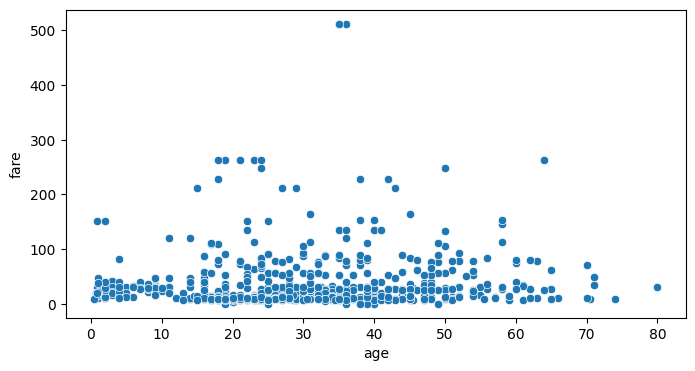

In [42]:
plt.figure(figsize=(8, 4))

sns.scatterplot(data=df, x="age", y="fare")

plt.show()

🧩 Do you observe a clear relationship between age and fare?

We can add a **regression line** to make the overall linear trend easier to see.

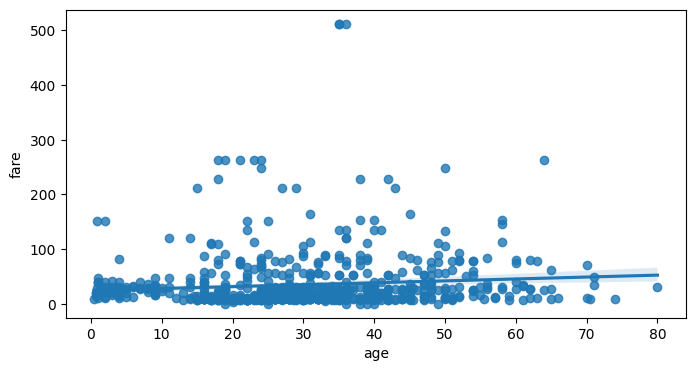

In [43]:
plt.figure(figsize=(8, 4))

sns.regplot(data=df, x="age", y="fare")

plt.show()

🧩 Does the regression line suggest a strong relationship between age and fare?

In [39]:
df[["age", "fare"]].corr()

,age,fare
age,1.000000,0.096067
fare,0.096067,1.000000


💡 The correlation coefficient "r" measures the strength and direction of a linear relationship between two numerical variables. It ranges from -1 to 1.  
Here, r≈ 0.1, indicating a very weak positive linear relationship between age and fare.

🧩 What does the correlation of approximately 0.10 suggest about the relationship between age and fare?

#### 5. Exploring Correlations

What Does Correlation Look Like?

Before calculating correlations in the Titanic dataset, let's look at some simple examples.

In [44]:
np.random.seed(42)

x = np.arange(50)

y_strong = 2 * x + np.random.normal(0, 5, 50)
y_weak = 0.3 * x + np.random.normal(0, 15, 50)
y_none = np.random.normal(0, 20, 50)

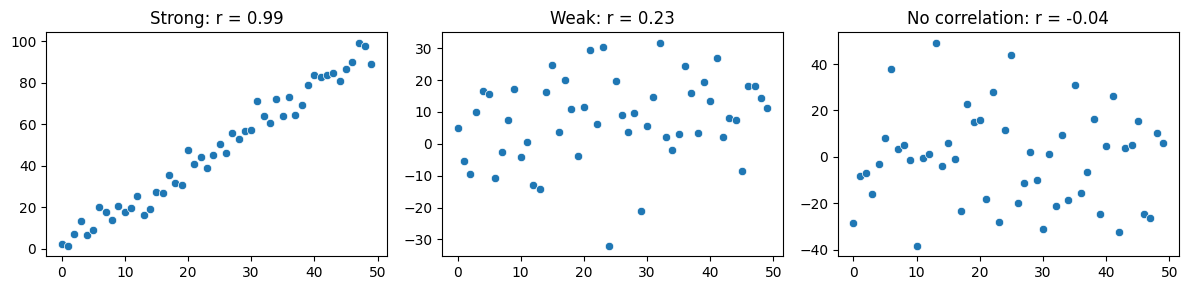

In [45]:
plt.figure(figsize=(12, 3))

plt.subplot(1, 3, 1)
sns.scatterplot(x=x, y=y_strong)
plt.title(f"Strong: r = {np.corrcoef(x, y_strong)[0, 1]:.2f}")

plt.subplot(1, 3, 2)
sns.scatterplot(x=x, y=y_weak)
plt.title(f"Weak: r = {np.corrcoef(x, y_weak)[0, 1]:.2f}")

plt.subplot(1, 3, 3)
sns.scatterplot(x=x, y=y_none)
plt.title(f"No correlation: r = {np.corrcoef(x, y_none)[0, 1]:.2f}")

plt.tight_layout()
plt.show()

Now let's see what relationships we can find in the Titanic dataset.

In [46]:
numeric_vars = df[["age", "fare", "sibsp", "parch"]]

numeric_vars.corr()

,age,fare,sibsp,parch
age,1.000000,0.096067,-0.308247,-0.189119
fare,0.096067,1.000000,0.159651,0.216225
sibsp,-0.308247,0.159651,1.000000,0.414838
parch,-0.189119,0.216225,0.414838,1.000000


🧩 Are there any strong linear relationships between these numerical variables?

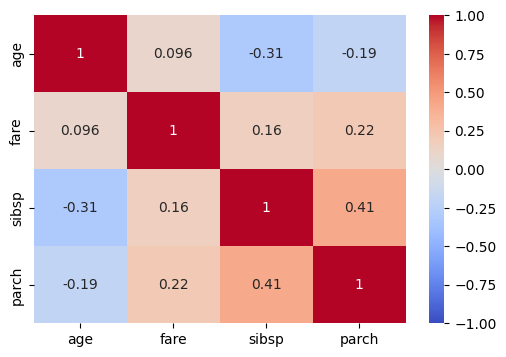

In [47]:
plt.figure(figsize=(6, 4))

sns.heatmap(numeric_vars.corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1)

plt.show()

🧩 Which pair of variables shows the strongest positive correlation? Which shows the strongest negative correlation?

💡Correlation does not imply causation. A correlation shows an association between variables, but it does not prove that one variable causes changes in the other.  
💡 Correlation measures linear relationships. A value close to zero does not necessarily mean that no relationship exists.

---
#### 🧩 PRACTICE 1: Age and Survival

Investigate whether the age distribution differs between passengers who survived and those who did not.

1. Choose an appropriate visualization to compare the age distributions between the two groups.
2. Compare suitable descriptive statistics for both groups.
3. What similarities or differences do you observe?

💡 Hint: You can use plt.subplot() to display the two distributions side by side.

In [49]:
age_survived = df[df["survived"] == 1]["age"]
age_not_survived = df[df["survived"] == 0]["age"]

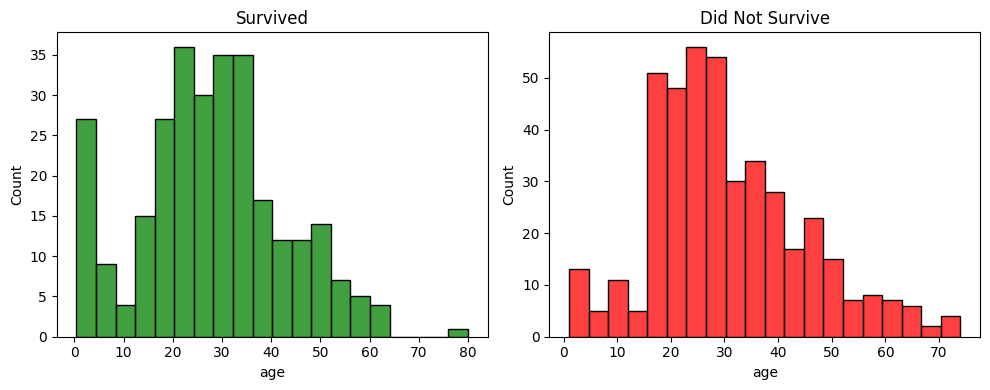

In [50]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(age_survived, color="green", bins=20)
plt.title("Survived")

plt.subplot(1, 2, 2)
sns.histplot(age_not_survived,color="red", bins=20)
plt.title("Did Not Survive")

plt.tight_layout()
plt.show()

In [51]:
df.groupby("survived")["age"].agg(["mean", "median", "std"])

,mean,median,std
survived,,,
0,30.626179,28.0,14.172110
1,28.343690,28.0,14.950952


🧩 The median age is the same for both groups. Does this mean that the age distributions are the same?

💡 Similar summary statistics do not necessarily mean that two distributions have the same shape. Visualizations and descriptive statistics should be interpreted together.

### 🧩 PRACTICE 2 – Does Travelling Alone Matter?

Investigate whether survival differed between passengers travelling alone and those travelling with others.

1. Choose an appropriate visualization.
2. Calculate the survival rate for each group.
3. What do you observe?

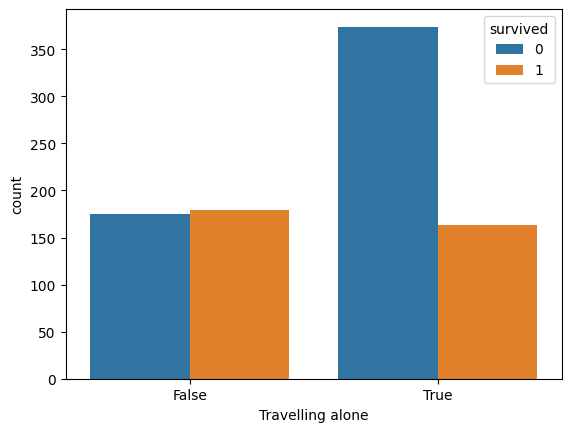

In [54]:
sns.countplot(data=df, x="alone", hue="survived")
plt.xlabel("Travelling alone")
plt.show()

In [53]:
df.groupby("alone")["survived"].mean()

alone
False    0.505650
True     0.303538
Name: survived, dtype: float64

🧩 How does the survival rate differ between passengers travelling alone and those travelling with others?

----

## 🎉 EDA: Completed ✓

####  <font color='#05c3de'> You survived the Titanic dataset. 🚢 </font>

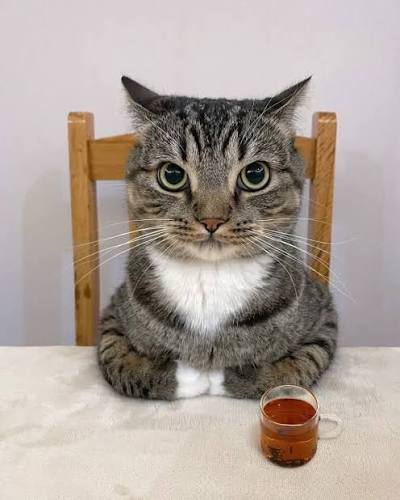